In [6]:
import pandas as pd
glass=pd.read_csv('glass.csv')

In [7]:
glass

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1.0
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1.0
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1.0
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1.0
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...
994,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
995,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
996,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
997,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
glass.shape

(999, 10)

In [9]:
glass.isnull().sum()

RI      785
Na      785
Mg      785
Al      785
Si      785
K       785
Ca      785
Ba      785
Fe      785
Type    785
dtype: int64

In [11]:
glass.info()

<class 'pandas.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    float64
dtypes: float64(10)
memory usage: 78.2 KB


In [12]:
glass['Type'].value_counts()

Type
2.0    76
1.0    70
7.0    29
3.0    17
5.0    13
6.0     9
Name: count, dtype: int64

In [13]:
glass.dropna(inplace=True)

In [15]:
glass.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [16]:
glass['Type']=glass['Type'].astype(int)

In [17]:
glass.info()

<class 'pandas.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int32  
dtypes: float64(9), int32(1)
memory usage: 16.0 KB


In [18]:
glass.shape

(214, 10)

In [19]:
glass.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X=glass.drop('Type',axis=1)
y=glass['Type']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)
scale=StandardScaler()
X_train_scaled=scale.fit_transform(X_train)
X_test_scaled=scale.transform(X_test)

In [23]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
rf_model=RandomForestClassifier(n_estimators=100,max_depth=5,max_features='sqrt',random_state=42)
rf_model.fit(X_train_scaled,y_train)
predict=rf_model.predict(X_test_scaled)
print(f"The accuracy Score of rf_model is : {accuracy_score(y_test,predict)*100:.2f}%")
print(f"Classification report of rf_model is : \n{classification_report(y_test,predict)}")
print(f"the Confusion Matrix of rf_model is : {confusion_matrix(y_test,predict)}")

The accuracy Score of rf_model is : 76.74%
Classification report of rf_model is : 
              precision    recall  f1-score   support

           1       0.65      1.00      0.79        11
           2       0.73      0.57      0.64        14
           3       1.00      0.33      0.50         3
           5       1.00      0.50      0.67         4
           6       1.00      1.00      1.00         3
           7       0.89      1.00      0.94         8

    accuracy                           0.77        43
   macro avg       0.88      0.73      0.76        43
weighted avg       0.80      0.77      0.75        43

the Confusion Matrix of rf_model is : [[11  0  0  0  0  0]
 [ 5  8  0  0  0  1]
 [ 1  1  1  0  0  0]
 [ 0  2  0  2  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


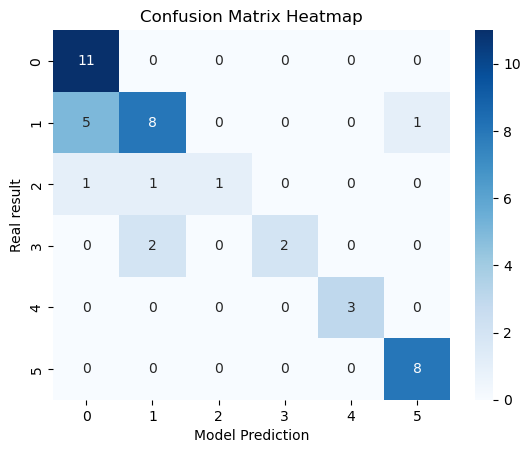

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,predict)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Model Prediction")
plt.ylabel("Real result")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [26]:
from sklearn.model_selection import GridSearchCV
param_grid={
    'n_estimators':[25,50,75,100,150,225],
    'max_depth':[5,10,15,20,25],
    'max_features':['sqrt','log2']
}
grid_search=GridSearchCV(estimator=RandomForestClassifier(random_state=42),param_grid=param_grid,cv=5,n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("Best Parameters are: ",grid_search.best_params_)

Best Parameters are:  {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 100}


In [29]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
rf_model1=RandomForestClassifier(n_estimators=100,max_depth=10,max_features='sqrt',random_state=42)
rf_model1.fit(X_train_scaled,y_train)
predict1=rf_model1.predict(X_test_scaled)
print(f"The accuracy Score of rf_model1 is : {accuracy_score(y_test,predict1)*100:.2f}%")
print(f"Classification report of rf_model1 is : \n{classification_report(y_test,predict1)}")
print(f"the Confusion Matrix of rf_model1 is : {confusion_matrix(y_test,predict1)}")

The accuracy Score of rf_model1 is : 86.05%
Classification report of rf_model1 is : 
              precision    recall  f1-score   support

           1       0.69      1.00      0.81        11
           2       0.91      0.71      0.80        14
           3       1.00      0.67      0.80         3
           5       1.00      0.75      0.86         4
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         8

    accuracy                           0.86        43
   macro avg       0.93      0.86      0.88        43
weighted avg       0.89      0.86      0.86        43

the Confusion Matrix of rf_model1 is : [[11  0  0  0  0  0]
 [ 4 10  0  0  0  0]
 [ 1  0  2  0  0  0]
 [ 0  1  0  3  0  0]
 [ 0  0  0  0  3  0]
 [ 0  0  0  0  0  8]]


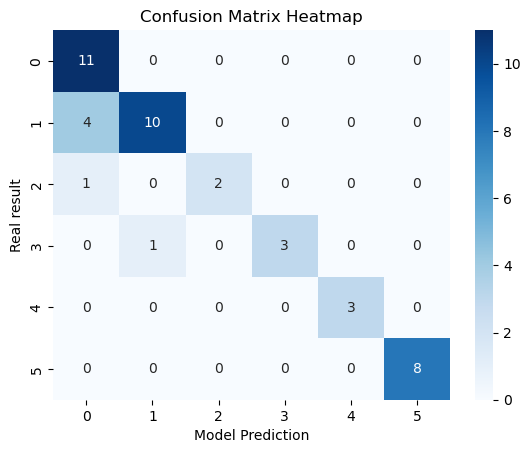

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
cm=confusion_matrix(y_test,predict1)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.xlabel("Model Prediction")
plt.ylabel("Real result")
plt.title("Confusion Matrix Heatmap")
plt.show()

In [31]:
importances = rf_model1.feature_importances_
feature_imp_df = pd.DataFrame({
    'Chemicals': X.columns, 
    'Importance_Score': importances
}).sort_values(by='Importance_Score', ascending=False)

In [32]:
feature_imp_df

,Chemicals,Importance_Score
2,Mg,0.162743
3,Al,0.159409
0,RI,0.148768
6,Ca,0.133410
1,Na,0.109089
4,Si,0.088364
5,K,0.088321
7,Ba,0.062972
8,Fe,0.046924


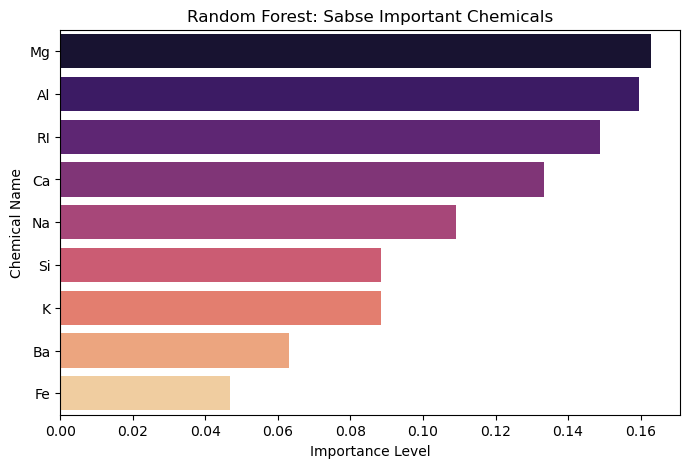

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(x='Importance_Score', y='Chemicals', data=feature_imp_df, palette='magma')
plt.title("Random Forest: Most Important Chemicals")
plt.xlabel("Importance Level")
plt.ylabel("Chemical Name")
plt.show()

## FINAL BUSINESS REPORT & CONCLUSION

**1. Business Objective Achieved:**
The goal of this project was to accurately classify the 'Type' of glass based on its chemical properties (RI, Na, Mg, Al, Si, K, Ca, Ba, Fe) to assist in forensic or manufacturing identification.

**2. Model Performance Summary:**
* **Baseline Model:** A default Random Forest Classifier achieved an accuracy of **76.74%**. The model struggled specifically between Class 1 (Building Window) and Class 2 (Vehicle Window) due to their similar chemical compositions.
* **Optimized Model:** After applying Hyperparameter Tuning using `GridSearchCV` (best parameters: `max_depth=10`, `n_estimators=100`, `max_features='sqrt'`), the model's accuracy surged to **86.05%**. The confusion matrix showed a significant reduction in misclassifications between Class 1 and Class 2.

**3. Key Business Insights (Feature Importance):**
By extracting the feature importance from our optimized model, we identified the primary chemical drivers for glass classification:
1. **Magnesium (Mg - 16.2%)**
2. **Aluminium (Al - 15.9%)**
3. **Refractive Index (RI - 14.8%)**
*Conclusion:* If the laboratory wants to quickly identify a glass type, they should prioritize testing for Magnesium and Aluminium concentrations first, as they hold the highest predictive power.

## ASSIGNMENT THEORY QUESTIONS

**Q1. What is a Random Forest and how does it work?**

 Random Forest is an ensemble machine learning algorithm. Instead of relying on a single Decision Tree, it builds a "forest" of multiple decision trees during training. For classification tasks, each tree in the forest makes a prediction (votes), and the Random Forest assigns the class that receives the majority of the votes. This majority-voting mechanism prevents the model from relying on the errors of any single tree.

**Q2. How does Random Forest prevent Overfitting?**

It prevents overfitting through two main techniques:
* **Row Sampling (Bagging):** Each tree is trained on a random subset of the data rows (with replacement).
* **Feature Sampling:** At each node split, the tree is only allowed to look at a random subset of features (usually the square root of total features). This ensures diversity among the trees, making the overall model highly robust and less prone to memorizing the training data.